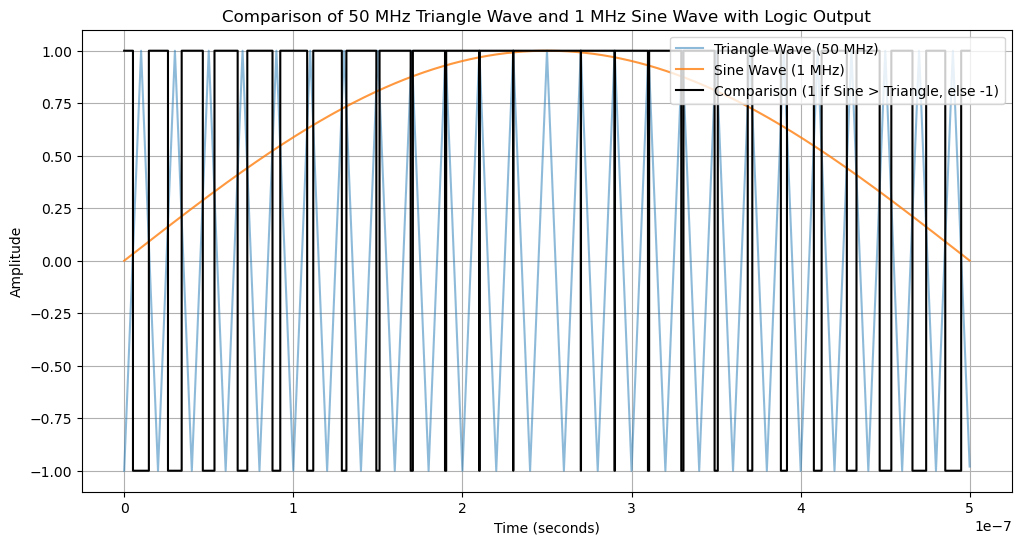

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

# Frequencies
frequency_tri = 50e6  # 50 MHz Triangle wave
frequency_sine = 1e6  # 1 MHz Sine wave

amplitude = 1

# Duration: show 2 full cycles of the 1 MHz sine wave
duration = 1 / (2*frequency_sine)

# Sample fast enough to resolve harmonics of the 50 MHz triangle wave
# (triangle waves have significant energy well above the fundamental)
sampling_period = 1e-10  # 1 GHz sampling rate -> Nyquist = 500 MHz

t = np.arange(0, duration, sampling_period)

# Generate waves
triangle_wave = amplitude * signal.sawtooth(2 * np.pi * frequency_tri * t, width=0.5)
sine_wave = amplitude * np.sin(2 * np.pi * frequency_sine * t)

# Generate the third square-like signal based on the condition
comparison_signal = np.where(sine_wave > triangle_wave, 1, -1)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(t, triangle_wave, label=f"Triangle Wave ({frequency_tri/1e6:.0f} MHz)", alpha=0.5)
plt.plot(t, sine_wave, label=f"Sine Wave ({frequency_sine/1e6:.0f} MHz)", alpha=0.8)

# Using step plot to cleanly show the sudden transitions of the third signal
plt.step(t, comparison_signal, label="Comparison (1 if Sine > Triangle, else -1)", color='black', linewidth=1.5, where='post')

plt.title("Comparison of 50 MHz Triangle Wave and 1 MHz Sine Wave with Logic Output")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc="upper right")
plt.show()

Now lets see the signal in the frequency domain. Run with more points first.

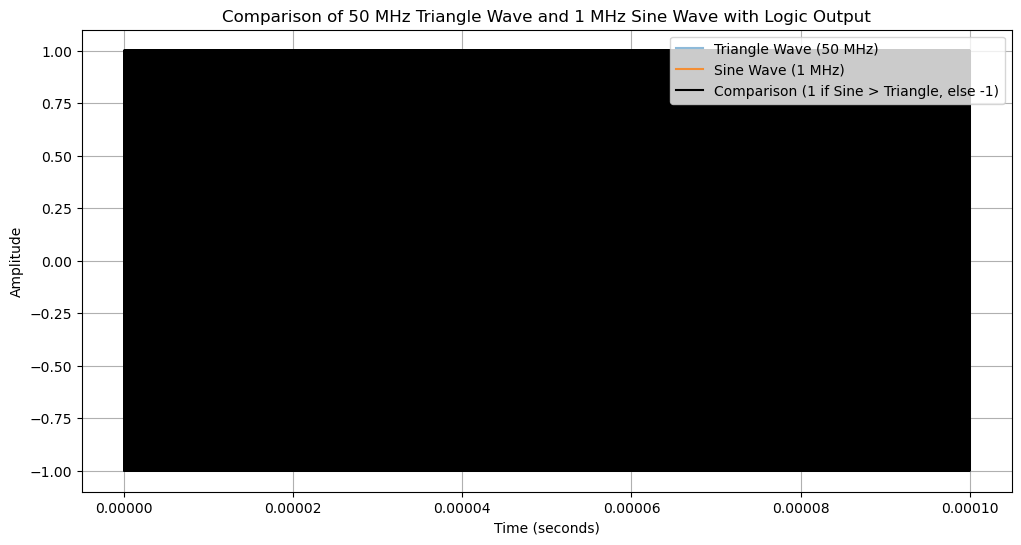

In [7]:
# Frequencies
frequency_tri = 50e6  # 50 MHz Triangle wave
frequency_sine = 1e6  # 1 MHz Sine wave

amplitude = 1

# Duration: show 2 full cycles of the 1 MHz sine wave
duration = 100 / (frequency_sine)

# Sample fast enough to resolve harmonics of the 50 MHz triangle wave
# (triangle waves have significant energy well above the fundamental)
sampling_period = 1e-10  # 1 GHz sampling rate -> Nyquist = 500 MHz

t = np.arange(0, duration, sampling_period)

# Generate waves
triangle_wave = amplitude * signal.sawtooth(2 * np.pi * frequency_tri * t, width=0.5)
sine_wave = amplitude * np.sin(2 * np.pi * frequency_sine * t)

# Generate the third square-like signal based on the condition
comparison_signal = np.where(sine_wave > triangle_wave, 1, -1)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(t, triangle_wave, label=f"Triangle Wave ({frequency_tri/1e6:.0f} MHz)", alpha=0.5)
plt.plot(t, sine_wave, label=f"Sine Wave ({frequency_sine/1e6:.0f} MHz)", alpha=0.8)

# Using step plot to cleanly show the sudden transitions of the third signal
plt.step(t, comparison_signal, label="Comparison (1 if Sine > Triangle, else -1)", color='black', linewidth=1.5, where='post')

plt.title("Comparison of 50 MHz Triangle Wave and 1 MHz Sine Wave with Logic Output")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc="upper right")
plt.show()

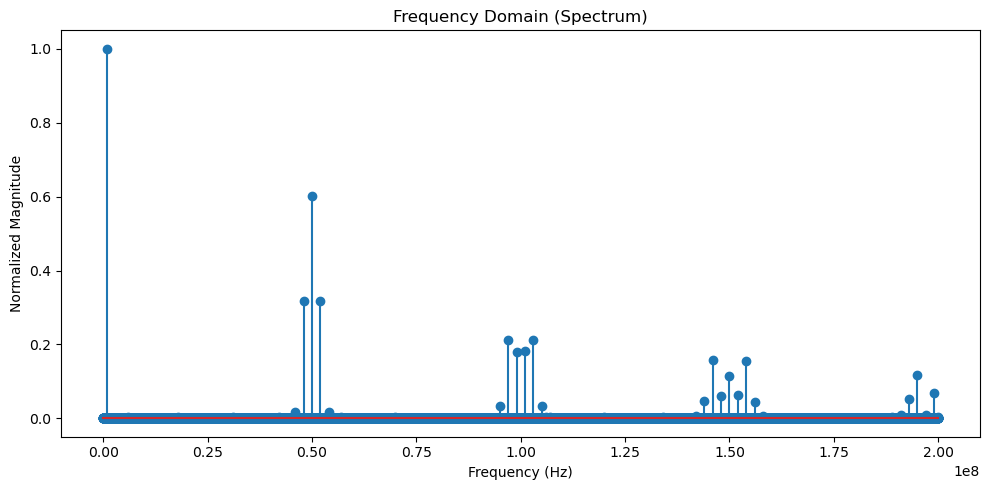

In [16]:


# Move to the Frequency Domain using FFT
fft_output = fft(comparison_signal)
frequencies = fftfreq(len(t), sampling_period)

# Get the positive frequencies only, normalized
positive_frequencies_mask = frequencies >= 0
freqs_side = frequencies[positive_frequencies_mask]
fft_side = np.abs(fft_output[positive_frequencies_mask]) / len(t)
fft_side[1:] = fft_side[1:] * 2  # Double amplitude for all except DC

# Plot, zoomed by frequency value (not a fragile index slice)
max_freq_to_show = 200e6  # show up to 200 MHz
plot_mask = freqs_side <= max_freq_to_show

plt.figure(figsize=(10, 5))
plt.stem(freqs_side[plot_mask], fft_side[plot_mask])
plt.title("Frequency Domain (Spectrum)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Magnitude")
plt.tight_layout()
plt.show()

plot in dB scale

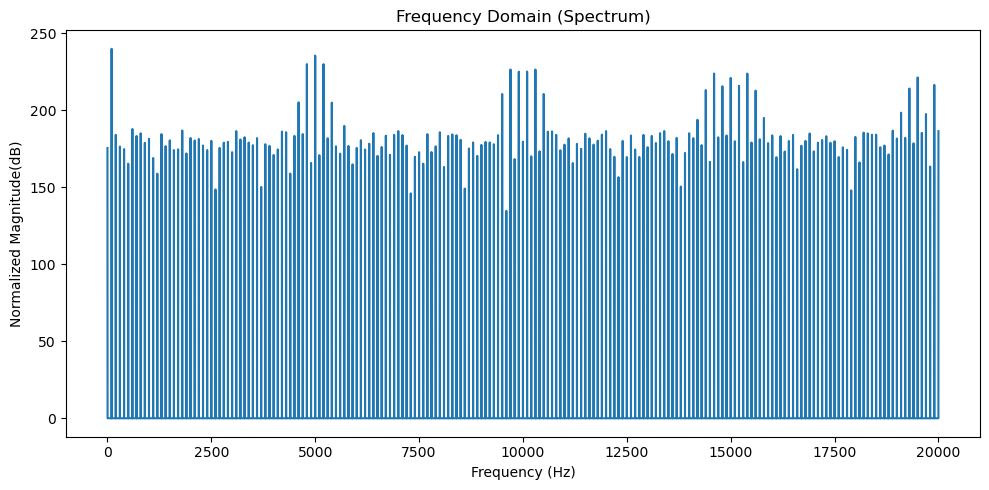

0.0


In [28]:
mag_dB_normalized=20*np.log10(np.clip(fft_side[plot_mask], 1e-12, None)) - 20*np.ones(len(fft_side[plot_mask]))*np.min(np.log10(np.clip(fft_side[plot_mask], 1e-12, None)))
plt.figure(figsize=(10, 5))
# plt.stem(freqs_side[plot_mask], mag_dB_normalized)
plt.plot(mag_dB_normalized)
plt.title("Frequency Domain (Spectrum)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Magnitude(dB)")
plt.tight_layout()
plt.show()
print(np.min(mag_dB_normalized))

now lets filter

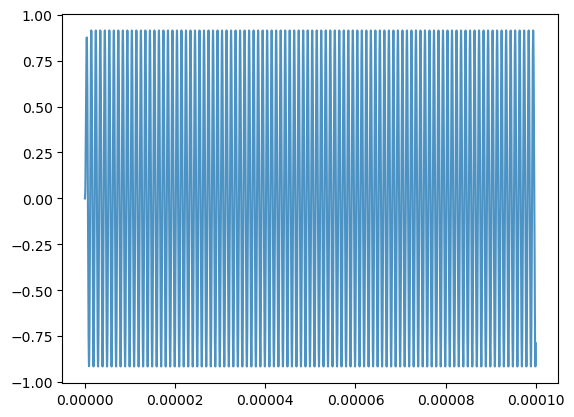

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfilt, sosfiltfilt

# 1. Define Filter Parameters
fs = 1/sampling_period       # Sampling frequency (Hz)
cutoff = 1.5e6     # Desired cutoff frequency (Hz)
order = 2         # 2nd-order filter

# 2. Design the Filter
# 'nyq' is the Nyquist frequency (half the sampling rate)
nyq = 0.5 * fs
normal_cutoff = cutoff / nyq

# Generate second-order sections (sos) of the filter
sos = butter(order, normal_cutoff, btype='low', output='sos')


# 4. Apply the Filter
# 'sosfilt' applies the filter forward (introduces a small phase shift)
# For zero-phase delay (forward & backward filtering), use 'sosfiltfilt'
filtered_signal = sosfilt(sos, comparison_signal)
plt.plot(t, filtered_signal, label=f"Filtered Signal", alpha=0.8)


frequency domain filtered signal

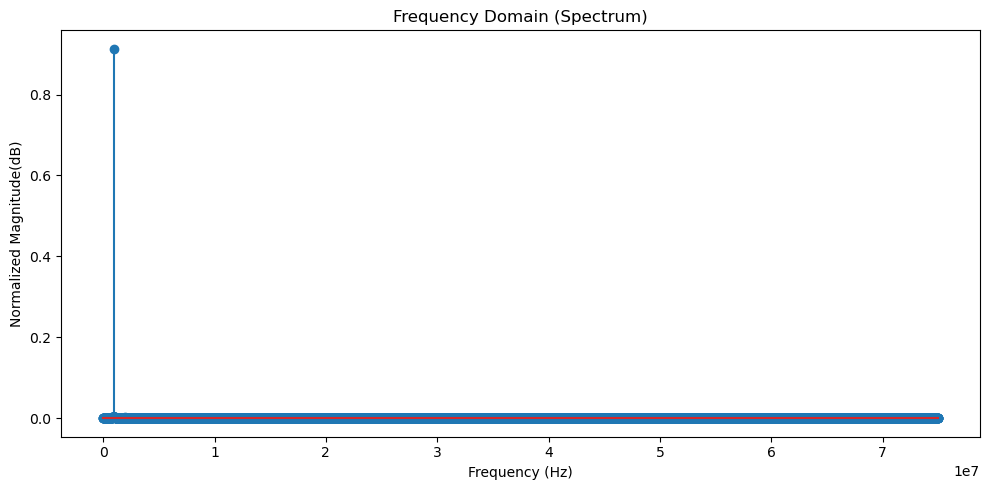

In [30]:


# Move to the Frequency Domain using FFT
fft_output = fft(filtered_signal)
frequencies = fftfreq(len(t), sampling_period)

# Get the positive frequencies only, normalized
positive_frequencies_mask = frequencies >= 0
freqs_side = frequencies[positive_frequencies_mask]
fft_side = np.abs(fft_output[positive_frequencies_mask]) / len(t)
fft_side[1:] = fft_side[1:] * 2  # Double amplitude for all except DC

# Plot, zoomed by frequency value (not a fragile index slice)
max_freq_to_show = 75e6  # show up to 200 MHz
plot_mask = freqs_side <= max_freq_to_show

plt.figure(figsize=(10, 5))
plt.stem(freqs_side[plot_mask], fft_side[plot_mask])
plt.title("Frequency Domain (Spectrum)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Magnitude(dB)")
plt.tight_layout()
plt.show()

now express in log scale

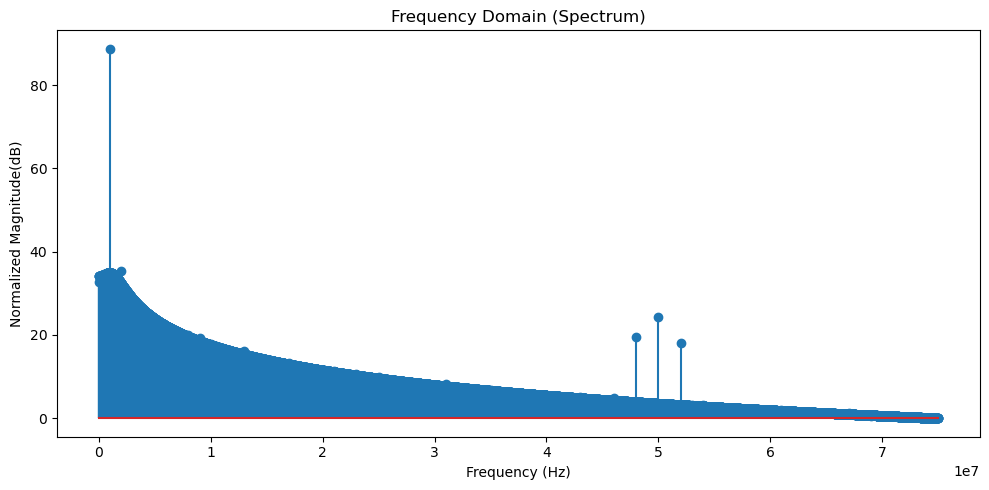

In [31]:

mag_dB_normalized=20*np.log10(fft_side[plot_mask]) - 20*np.ones(len(fft_side[plot_mask]))*np.min(np.log10(fft_side[plot_mask]))
plt.figure(figsize=(10, 5))
plt.stem(freqs_side[plot_mask], mag_dB_normalized)
plt.title("Frequency Domain (Spectrum)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Magnitude(dB)")
plt.tight_layout()
plt.show()

Not sure why there's a noise profile. In theory there should only be signal at the fundumental and harmonics.